In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import shap
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
# from MODELS.pipeline import *
# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

In [34]:

pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
for df in [s20,s21,s22,s23,s24,s25,s26]:
    df['IS_HIGH_SCORER'] = (df.groupby('PLAYER_ID')['PTS_AVG_TO_DATE'].transform('mean') > 18).astype(int)

def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s19,s20,s21,s22,s23])
# train_df = train_df[train_df['MIN'] > 10]  
# train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
val_df = s24
# val_df = val_df[val_df['MIN'] > 10] 
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

#test data
test_df = s25
# test_df = test_df[test_df['MIN'] > 10] 
# test_df = cap_outliers_per_player(test_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")
train_df.sample(5)

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_6202/2900643985.py:10: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Train set: 123509 samples
Val set: 26401 samples
Test set: 26306 samples


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS_AVG_TO_D

In [24]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', 
    'IS_ROLE_TIER', 
    'IS_BENCH_TIER', 
    'STARTING_X_STARTER_TIER', #new
    'STARTING_X_BENCH_TIER', 
    'STARTING_X_ROLE_TIER', 
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'FGA_X_STAR_PLAYER', #new
    'USG_PCT_X_STAR_PLAYER', #new
    'USG_X_STARTER_TIER', #new 
    'PTS_X_STARTER_TIER', #new
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'GAMES_THIS_SEASON', 

    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'MIN_VOLATILITY_40_TO_DATE', 
    'MIN_ROLLING_AVG_40', 
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',  
    'PTS_ROLLING_AVG_40', 
    'PTS_TREND_LAST_5', 
    'MIN_TREND_LAST_5', 
    'PTS_PER_MIN_X_USG',
    'PTS_VOLATILITY_5_TO_DATE', 
    'FGA_LAG_1',
    'FGM_VOLATILITY_5_TO_DATE', 
    'FGM_VOLATILITY_10_TO_DATE', 
    'FGM_VOLATILITY_40_TO_DATE', 
    'FGA_VOLATILITY_5_TO_DATE', 
    'FGA_VOLATILITY_10_TO_DATE', 
    'FGA_VOLATILITY_40_TO_DATE', 
    '3PA_RATE',
    'USG_PCT_LAG_1',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', 
    'USG_PCT_CV_40_TO_DATE', 
    'TS_PCT_CV_5_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE', 
    'TS_PCT_CV_40_TO_DATE', 
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10', 
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'USAGE_X_EFFICIENCY', 
    'PTS_PER_POSSESSION', 
    'PACE_VOLATILITY_5_TO_DATE', 
    'PACE_VOLATILITY_10_TO_DATE', 
    'PACE_VOLATILITY_20_TO_DATE', 
    'PACE_VOLATILITY_40_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_5_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_10_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_40_TO_DATE', 
    'NET_RATING_VOLATILITY_5_TO_DATE', 
    'NET_RATING_VOLATILITY_10_TO_DATE', 
    'NET_RATING_VOLATILITY_40_TO_DATE', 
    'FG_PCT_CV_5_TO_DATE', 
    'FG_PCT_CV_10_TO_DATE',
    'FG_PCT_CV_40_TO_DATE', 
    'FG3A_VOLATILITY_5_TO_DATE', 
    'FG3A_VOLATILITY_10_TO_DATE', 
    'FG3A_VOLATILITY_40_TO_DATE', 
    'FG3M_VOLATILITY_5_TO_DATE', 
    'FG3M_VOLATILITY_10_TO_DATE', 
    'FG3M_VOLATILITY_40_TO_DATE', 
    'FG3_PCT_CV_5_TO_DATE', 
    'FG3_PCT_CV_10_TO_DATE', 
    'FG3_PCT_CV_20_TO_DATE', 
    'FG3_PCT_CV_40_TO_DATE', 
    'FTA_VOLATILITY_5_TO_DATE', 
    'FTA_VOLATILITY_10_TO_DATE', 
    'FTM_VOLATILITY_5_TO_DATE', 
    'FTM_VOLATILITY_10_TO_DATE', 
    'FTM_VOLATILITY_40_TO_DATE', 
    'FT_PCT_CV_5_TO_DATE',
    'FT_PCT_CV_10_TO_DATE', 
    'FT_PCT_CV_20_TO_DATE',
    'FT_PCT_CV_40_TO_DATE', 
    'TOV_VOLATILITY_10_TO_DATE', 
    'FGA_ROLLING_AVG_10', 
    'EXPECTED_USAGE_MIN', 
    'PTS_RECENT_VS_SEASON', #new
    'HOT_STREAK', #new 
    'COLD_STREAK', #new
    'ELITE_USAGE', #new
    'HIGH_USAGE', #new
    'PTS_MAX_LAST_10', #new
    'PTS_MIN_LAST_10', #new
    'STAR_HOT_HAND', #new
    'IS_HIGH_SCORER', #new
    'PLAYER_PTS_SHARE', #new
    'PLAYER_FGA_SHARE', #new
    'PTS_CEILING', #new

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_GUARD_3PT_DEF_ALLOWED', 
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',

    'OPP_FORWARD_DEF_RATING',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_FORWARD_3PT_DEF_ALLOWED', 
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',

    'OPP_CENTER_DEF_RATING',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_CENTER_3PT_DEF_ALLOWED', 
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL', #new 

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_AVG_FGA_TO_DATE', #new
    'PLAYER_HOME_FTA_DELTA',
    'PTS_BASELINE_x_HOME', 
    'MATCHUP_AVG_PTS_TO_DATE',
    'GAMES_VS_OPP' 
 ]

In [35]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', 
    'IS_ROLE_TIER', 
    'IS_BENCH_TIER', 
    'STARTING_X_STARTER_TIER', #new
    'STARTING_X_BENCH_TIER', 
    'STARTING_X_ROLE_TIER', 
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'FGA_X_STAR_PLAYER', #new
    'USG_PCT_X_STAR_PLAYER', #new
    'USG_X_STARTER_TIER', #new 
    'PTS_X_STARTER_TIER', #new
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'GAMES_THIS_SEASON', 

    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_40_TO_DATE',
    'MIN_ROLLING_AVG_40',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',
    'PTS_ROLLING_AVG_40',
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_PER_MIN_X_USG',
    'PTS_VOLATILITY_5_TO_DATE',
    'FGA_LAG_1',
    'FGM_VOLATILITY_5_TO_DATE',
    'FGM_VOLATILITY_10_TO_DATE',
    'FGM_VOLATILITY_40_TO_DATE',
    'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_40_TO_DATE',
    '3PA_RATE',
    'USG_PCT_LAG_1',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE',
    'USG_PCT_CV_40_TO_DATE',
    'TS_PCT_CV_5_TO_DATE',
    'TS_PCT_CV_10_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'USAGE_X_EFFICIENCY',
    'PTS_PER_POSSESSION',
    'PACE_VOLATILITY_5_TO_DATE',
    'PACE_VOLATILITY_10_TO_DATE',
    'PACE_VOLATILITY_20_TO_DATE',
    'PACE_VOLATILITY_40_TO_DATE',
    'E_OFF_RATING_VOLATILITY_5_TO_DATE',
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_40_TO_DATE',
    'NET_RATING_VOLATILITY_5_TO_DATE',
    'NET_RATING_VOLATILITY_10_TO_DATE',
    'NET_RATING_VOLATILITY_40_TO_DATE',
    'FG_PCT_CV_5_TO_DATE',
    'FG_PCT_CV_40_TO_DATE',
    'FG3A_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_40_TO_DATE',
    'FG3M_VOLATILITY_5_TO_DATE',
    'FG3M_VOLATILITY_40_TO_DATE',
    'FG3_PCT_CV_5_TO_DATE',
    'FG3_PCT_CV_10_TO_DATE',
    'FG3_PCT_CV_20_TO_DATE',
    'FTM_VOLATILITY_5_TO_DATE',
    'FTM_VOLATILITY_10_TO_DATE',
    'FTM_VOLATILITY_40_TO_DATE',
    'FT_PCT_CV_5_TO_DATE',
    'FT_PCT_CV_10_TO_DATE',
    'FT_PCT_CV_40_TO_DATE',
    'TOV_VOLATILITY_10_TO_DATE',
    'PTS_RECENT_VS_SEASON',
    'HOT_STREAK',
    'COLD_STREAK',
    'ELITE_USAGE',
    'HIGH_USAGE',
    'PTS_MAX_LAST_10',
    'PTS_MIN_LAST_10',
    'STAR_HOT_HAND',
    'IS_HIGH_SCORER',

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL',

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'MATCHUP_AVG_PTS_TO_DATE',
    'GAMES_VS_OPP'
]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [14]:
# from MODELS.xgboostModel import *

# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=30,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

Selected 30 total features
Top 10 most important:
1. PTS_ROLLING_AVG_40
2. PTS_BASELINE
3. USG_X_STARTER_TIER
4. EXPECTED_USAGE_MIN
5. PTS_X_OPP_DEF_RATING
6. PTS_AVG_TO_DATE
7. PTS_X_STARTER_TIER
8. FGA_ROLLING_AVG_40
9. STARTING_X_STARTER_TIER
10. FGA_AVG_TO_DATE


# XGBOOST MODEL

### Remove correlated features

In [ ]:
from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.90)

### NGBOOST MODEL

In [36]:

mean_model, variance_model, cal_factor = fit_ngboost_split(train_df,
                     val_df,
                     top_features,
                     target_col='PTS',
                     distribution=Normal,
                     player_col='PLAYER_ID',
                     recent_n=60,
                     recent_weight=2.0,
                     variance_recent_weight=1.0,
                     variance_lr=0.05,  # Higher learning rate for variance
                     variance_max_depth=6,  # Deeper trees for variance
                     variance_n_estimators=300,
                     variance_calibration_factor=1.25)  # Calibration to inflate variance


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.

=== PROBABILITY METRICS ===

Train - === PROBABILITY METRICS ===
Train - Prop Line: 9.00
Train - N Samples: 123509
Train - Positives: 58059, Negatives: 65450
Train - Brier Score: 0.1426 (lower is better)
Train - Log Loss: 0.4298 (lower is better)
Train - AUC-ROC: 0.8793 (higher is better)


Val - === PROBABILITY METRICS ===
Val - Prop Line: 9.00
Val - N Samples: 26401
Val - Positives: 12378, Negatives: 14023
Val - Brier Score: 0.1364 (lower is better)
Val - Log Loss: 0.4165 (lower is better)
Val - AUC-ROC: 0.8894 (higher is better)



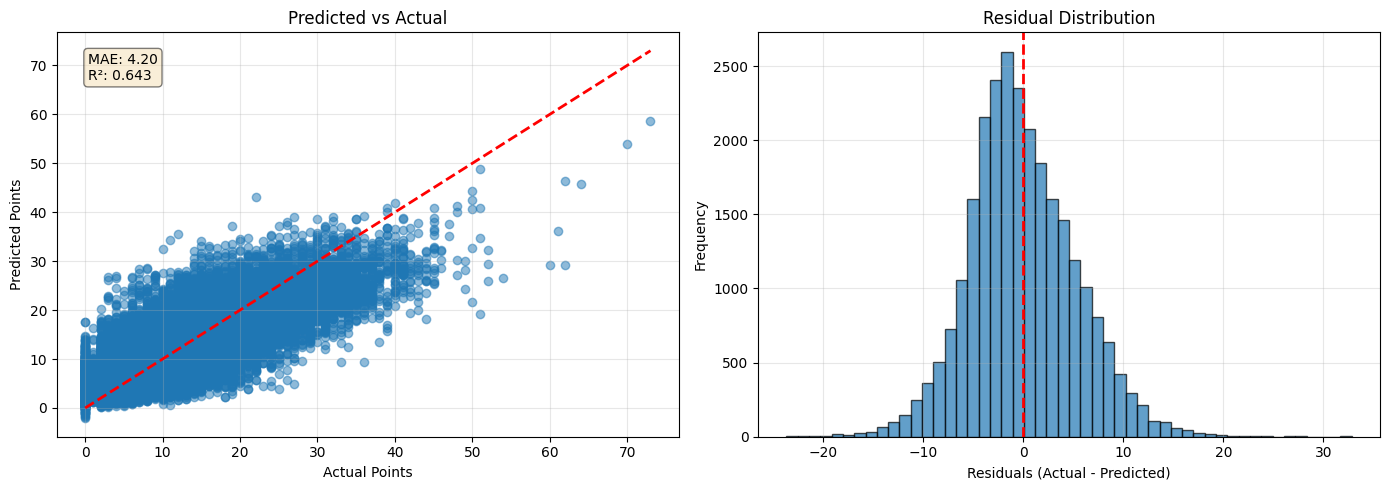

In [37]:
import matplotlib.pyplot as plt


preds_dist = mean_model.pred_dist(val_df[top_features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': top_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                  feature  mean_model
          PTS_MAX_LAST_10    0.157479
          PTS_MIN_LAST_10    0.063133
FGM_VOLATILITY_10_TO_DATE    0.059544
       PTS_ROLLING_AVG_40    0.043980
        GAMES_THIS_SEASON    0.030070
     OPP_GUARD_DEF_RATING    0.022869
     TS_PCT_CV_10_TO_DATE    0.021578
 PTS_VOLATILITY_5_TO_DATE    0.021061
                MIN_LAG_1    0.016567
         PTS_TREND_LAST_5    0.014543
       MIN_ROLLING_AVG_40    0.013735
       PTS_DELTA_STAR_OUT    0.013623
       PTS_PER_POSSESSION    0.013036
                FGA_LAG_1    0.012660
   OPP_FORWARD_DEF_RATING    0.012359
        PTS_PER_MIN_X_USG    0.011469
FTM_VOLATILITY_10_TO_DATE    0.010643
     PTS_RECENT_VS_SEASON    0.010626
         PLAYER_DAYS_REST    0.009985
 USUAL_STARTERS_AVAILABLE    0.009905


In [39]:
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                  feature  var_model
          PTS_MAX_LAST_10   0.282034
          PTS_MIN_LAST_10   0.058519
FGM_VOLATILITY_10_TO_DATE   0.043775
       PTS_ROLLING_AVG_40   0.023858
        GAMES_THIS_SEASON   0.011421
     OPP_GUARD_DEF_RATING   0.018056
     TS_PCT_CV_10_TO_DATE   0.012978
 PTS_VOLATILITY_5_TO_DATE   0.022937
                MIN_LAG_1   0.011719
         PTS_TREND_LAST_5   0.009182
       MIN_ROLLING_AVG_40   0.014976
       PTS_DELTA_STAR_OUT   0.006574
       PTS_PER_POSSESSION   0.011997
                FGA_LAG_1   0.009529
   OPP_FORWARD_DEF_RATING   0.010040
        PTS_PER_MIN_X_USG   0.007898
FTM_VOLATILITY_10_TO_DATE   0.007445
     PTS_RECENT_VS_SEASON   0.006624
         PLAYER_DAYS_REST   0.003814
 USUAL_STARTERS_AVAILABLE   0.005477


In [40]:
validate_production_model(mean_model, variance_model, val_df, top_features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: -0.021 (should be ~0)
Standardized residuals std: 0.978 (should be ~1)
Q10: Predicted=4.2, Actual=0.0
Q25: Predicted=7.3, Actual=3.0
Q50: Predicted=10.7, Actual=9.0
Q75: Predicted=14.2, Actual=16.0
Q90: Predicted=17.3, Actual=23.0

MAE: 4.20
90% CI: Coverage=93.13%, Expected=90.00%
95% CI: Coverage=97.45%, Expected=95.00%
99% CI: Coverage=99.41%, Expected=99.00%


array([-0.33939519,  0.65603548,  1.25624644, ...,  0.54892079,
       -0.52980442, -1.63978773], shape=(26401,))

In [41]:
import joblib

# Save NGBoost split models (mean, variance, and calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']